In [1]:
# Add algorithm directory to path to import local modules if needed
import sys
import pandas as pd
import os
import numpy as np
sys.path.append(os.path.abspath("algorithm"))
from pathlib import Path
import sys

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from src.hcm_transcription.mapping import MAPPING

# Mapping for ornamentation types
ORNAMENT_MAPPING = {
    "k": "Kan",
    "g": "Gamak",
    "mu": "Murki",
    "me": "Meend",
    "a": "Andolan",
    "kh": "Khatka",
    "z": "Zamzama",
    "o": "Other"
}
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def df_to_anno(df):
    """
    Parses the annotation CSV into a structured DataFrame with start/end times.
    Borrowed and adapted from algorithm/evaluation.py
    """
    all_index = []
    # Ensure column names are set
    df.columns = ["time", "label"]
    
    for index, label in enumerate(df.label):
        # remove none, blanks, etc.
        if label == 'none' or label == '' or label == 'Q':
            all_index.append(index)
            
    df_new = df.drop(all_index)
    df_new = df_new.reset_index(drop=True)

    time_s = []
    time_e = []
    labels = []
    
    # Iterate in steps of 2 assuming start and end pairs
    for i in range(0, len(df_new) - 1, 2):
        s = i
        e = i + 1
        
        # Basic validation that it's a pair
        label_s = str(df_new['label'].iloc[s])
        label_e = str(df_new['label'].iloc[e])
        
        if label_s.endswith('_s') and label_e.endswith('_e'):
            time_s.append(df_new['time'].iloc[s])
            time_e.append(df_new['time'].iloc[e])
            
            # Map the prefix to the full name
            raw_label = label_s[:-2] # remove '_s'
            
            if raw_label.startswith('c_'):
                # Compound label: c_k_me -> Kan + Meend
                parts = raw_label.split('_')[1:] # Skip the 'c'
                mapped_parts = [ORNAMENT_MAPPING.get(p, p) for p in parts]
                labels.append(" + ".join(mapped_parts))
            else:
                # Simple label: me -> Meend
                labels.append(ORNAMENT_MAPPING.get(raw_label, raw_label))
        else:
            # Handle cases where they might not be perfectly paired or none/other labels shifted them
            print(f"Warning: Unexpected pair at index {i}: {label_s}, {label_e}")
            
    anno = pd.DataFrame({
        'time_s': time_s,
        'time_e': time_e,
        'label': labels
    })
    anno['duration'] = anno['time_e'] - anno['time_s']
    return anno

In [3]:
def extract_ornament_segments(raga_names, data_home, annotation_base="Ornamentation-In-Hindustani-Vocals-Dataset"):

    TARGET_LABELS = {"Kan", "Meend", "Murki", "Andolan"}
    segments = []

    for raga_name in raga_names:
        if raga_name not in MAPPING:
            print(f"Skipping {raga_name} - not in MAPPING")
            continue

        data = MAPPING[raga_name]
        annotation_file = f"{annotation_base}/{list(data['annotators'].values())[0]}"

        # Build pitch path directly from audio_path — no compiam needed
        pitch_path = f"{data_home}/saraga1.5_hindustani/{data['audio_path']}.pitch.txt"

        print(f"Loading {raga_name}...")
        print(f"  Pitch: {pitch_path}")

        if not os.path.exists(pitch_path):
            print(f"  WARNING: pitch file not found, skipping")
            continue

        if not os.path.exists(annotation_file):
            print(f"  WARNING: annotation file not found, skipping")
            continue
        # Load pitch data
        df_pitch = pd.read_csv(pitch_path, sep="\t", header=None)
        df_pitch.columns = ["time", "f0"]
        df_pitch["log_f0"] = df_pitch["f0"].apply(lambda x: np.log2(x) if x > 0 else np.nan)

        # Load annotations
        df_raw = pd.read_csv(annotation_file, header=None)
        anno = df_to_anno(df_raw)

        # Filter to target labels only
        anno_filtered = anno[anno['label'].isin(TARGET_LABELS)].reset_index(drop=True)
        print(f"  Found {len(anno_filtered)} target ornaments out of {len(anno)} total")

        for _, row in anno_filtered.iterrows():
            mask = (df_pitch["time"] >= row['time_s']) & (df_pitch["time"] <= row['time_e'])
            segment_pitch = df_pitch[mask]["log_f0"].values

            if len(segment_pitch) == 0 or np.isnan(segment_pitch).mean() > 0.3:
                continue

            segment_pitch = pd.Series(segment_pitch).interpolate().fillna(0).values

            segments.append({
                "raga": raga_name,
                "label": row['label'],
                "time_s": row['time_s'],
                "time_e": row['time_e'],
                "duration": row['duration'],
                "pitch_curve": segment_pitch
            })

    # Summary
    df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} 
                                  for s in segments])
    print(f"\n=== Extraction Summary ===")
    print(f"Total segments: {len(segments)}")
    print(f"Label distribution:\n{df_segments['label'].value_counts()}")
    print(f"Duration stats:\n{df_segments['duration'].describe()}")

    return segments

In [4]:
raga_names = ["Aahir Bhairon", "Bairagi", "Bhairavi", "Irani Bhairavi", "Kalavati", "Malkauns", "Chandrakauns",
              "Majh Khamaj", "Nat Bhairon", "Raageshree", "Todi"]  # whatever is in your MAPPING
data_home = str(ROOT)
annotation_base = str(ROOT / "Ornamentation-In-Hindustani-Vocals-Dataset")

segments = extract_ornament_segments(raga_names, data_home, annotation_base)

# Inspect one segment
print(segments[0]['label'])
print(segments[0]['pitch_curve'])


Loading Aahir Bhairon...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Aahir Bhairon/Aahir Bhairon.pitch.txt
  Found 109 target ornaments out of 149 total
Loading Bairagi...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Bairagi/Bairagi.pitch.txt


  Found 65 target ornaments out of 89 total
Loading Bhairavi...
  Pitch: ../saraga1.5_hindustani/Raag Bihag & Bhairavi Dadra by Omkar Dadarkar/Bhairavi Dadra/Bhairavi Dadra.pitch.txt
  Found 23 target ornaments out of 67 total
Loading Irani Bhairavi...
  Pitch: ../saraga1.5_hindustani/New Signature by Brajeshwar Mukherjee/Irani Bhairavi Thumri/Irani Bhairavi Thumri.pitch.txt
  Found 83 target ornaments out of 103 total


Loading Kalavati...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Kalavati/Kalavati.pitch.txt
  Found 93 target ornaments out of 133 total
Loading Malkauns...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Malkauns/Malkauns.pitch.txt
  Found 46 target ornaments out of 73 total
Loading Chandrakauns...
  Pitch: ../saraga1.5_hindustani/Raag Malkauns, Chandrakauns & Majh Khamaj Thumri by Satyasheel Deshpande/Raag Chandrakauns/Raag Chandrakauns.pitch.txt
  Found 57 target ornaments out of 91 total
Loading Majh Khamaj...
  Pitch: ../saraga1.5_hindustani/Raag Malkauns, Chandrakauns & Majh Khamaj Thumri by Satyasheel Deshpande/Majh Khamaj Thumri/Majh Khamaj Thumri.pitch.txt


  Found 78 target ornaments out of 120 total
Loading Nat Bhairon...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Nat Bhairon/Nat Bhairon.pitch.txt
  Found 168 target ornaments out of 212 total
Loading Raageshree...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Raageshree/Raageshree.pitch.txt


  Found 129 target ornaments out of 159 total
Loading Todi...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Todi/Todi.pitch.txt
  Found 130 target ornaments out of 205 total

=== Extraction Summary ===
Total segments: 929
Label distribution:
label
Kan        380
Meend      363
Murki      154
Andolan     32
Name: count, dtype: int64
Duration stats:
count    929.000000
mean       0.651317
std        0.527361
min        0.017415
25%        0.300408
50%        0.522449
75%        0.802540
max        4.643991
Name: duration, dtype: float64
Meend
[7.21470138 7.20636799 7.19803461 7.18136794 7.16470104 7.1480343
 7.12303426 7.12303426 7.10636741 7.10636741 7.10636741 7.10636741
 7.10636741 7.11470092 7.12303426 7.12303426 7.13136763 7.13970107
 7.1480343  7.15636766 7.15636766 7.15636766 7.1480343  7.1480343
 7.13970107 7.13970107 7.13136763 7.13136763 7.13136763 7.12303426
 7.12303426 7.11470092 7.11470092 7.11470092 7.10636741 7.10636741
 7.10636741 7.09803401 7.

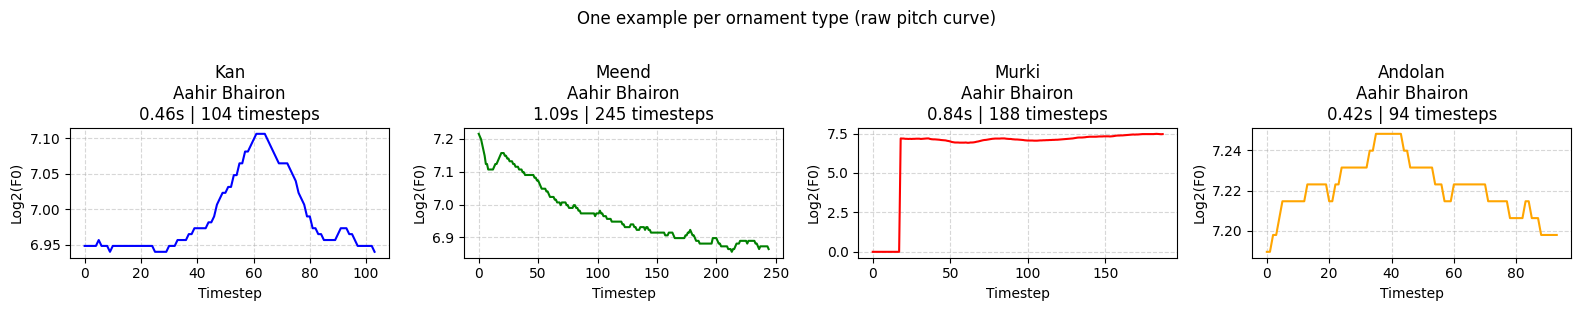

In [5]:
# Plot one example per class
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
colors = {"Kan": "blue", "Meend": "green", "Murki": "red", "Andolan": "orange"}

for ax, label in zip(axes, ["Kan", "Meend", "Murki", "Andolan"]):
    # Find first example of this label
    example = next((s for s in segments if s['label'] == label), None)
    
    if example is None:
        ax.set_title(f"{label}\n(not found)")
        continue
    
    curve = example['pitch_curve']
    ax.plot(curve, color=colors[label], linewidth=1.5)
    ax.set_title(f"{label}\n{example['raga']}\n{example['duration']:.2f}s | {len(curve)} timesteps")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Log2(F0)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("One example per ornament type (raw pitch curve)", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# Build summary dataframe
df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} for s in segments])
df_segments['num_timesteps'] = [len(s['pitch_curve']) for s in segments]

print("=== Class Distribution ===")
print(df_segments['label'].value_counts())

print("\n=== Duration Stats per Class (seconds) ===")
print(df_segments.groupby('label')['duration'].describe().round(3))

print("\n=== Timestep Stats per Class ===")
print(df_segments.groupby('label')['num_timesteps'].describe().round(1))

print("\n=== Duration Stats per Raga ===")
print(df_segments.groupby('raga')['duration'].describe().round(3))

=== Class Distribution ===
label
Kan        380
Meend      363
Murki      154
Andolan     32
Name: count, dtype: int64

=== Duration Stats per Class (seconds) ===
         count   mean    std    min    25%    50%    75%    max
label                                                          
Andolan   32.0  0.971  1.068  0.107  0.270  0.383  1.474  4.644
Kan      380.0  0.397  0.301  0.065  0.209  0.305  0.502  2.771
Meend    363.0  0.761  0.431  0.174  0.495  0.666  0.904  4.040
Murki    154.0  0.956  0.698  0.017  0.438  0.744  1.324  4.060

=== Timestep Stats per Class ===
         count   mean    std   min    25%    50%    75%     max
label                                                          
Andolan   32.0  218.5  240.4  24.0   60.0   86.5  331.8  1045.0
Kan      380.0   89.2   67.8  14.0   47.0   68.0  113.2   624.0
Meend    363.0  171.2   97.0  39.0  111.0  150.0  203.5   909.0
Murki    154.0  215.2  157.0   4.0   99.0  167.5  297.8   913.0

=== Duration Stats per Raga ===
  

In [7]:
lengths = [len(s['pitch_curve']) for s in segments]
print(f"min: {min(lengths)}")
print(f"max: {max(lengths)}")
print(f"mean: {np.mean(lengths):.0f}")
print(f"95th percentile: {np.percentile(lengths, 95):.0f}")

min: 4
max: 1045
mean: 147
95th percentile: 372


In [8]:
def augment_pitch_curve(curve, noise_std=0.01, stretch_range=(0.8, 1.2)):
    """
    Applies random augmentations to a pitch curve:
    - Gaussian noise
    - Time stretching (resampling)
    """
    from scipy.signal import resample
    
    # Random time stretch
    stretch_factor = np.random.uniform(*stretch_range)
    new_length = int(len(curve) * stretch_factor)
    curve = resample(curve, new_length)
    
    # Add small Gaussian noise
    #curve = curve + np.random.normal(0, noise_std, len(curve))
    
    return curve


def augment_segments(segments, num_augmentations=2):
    """
    Augments each segment num_augmentations times and adds to dataset.
    """
    augmented = []
    for seg in segments:
        augmented.append(seg)  # keep original
        
        for _ in range(num_augmentations):
            aug_curve = augment_pitch_curve(seg['pitch_curve'].copy())
            augmented.append({
                "raga": seg['raga'],
                "label": seg['label'],
                "time_s": seg['time_s'],
                "time_e": seg['time_e'],
                "duration": seg['duration'],
                "pitch_curve": aug_curve
            })
    
    print(f"Original: {len(segments)} → Augmented: {len(augmented)} segments")
    return augmented

segments_aug = augment_segments(segments, num_augmentations=2)

Original: 929 → Augmented: 2787 segments


### Preprocess

In [9]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

def prepare_tcn_input(segments, fixed_length=117):
    """
    Takes raw segments from extract_ornament_segments and prepares
    fixed-length numpy arrays for TCN training.
    """
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0

    # Filter too-short segments before processing
    segments = [s for s in segments if len(s['pitch_curve']) >= 20]
    
    for seg in segments:
        curve = seg['pitch_curve']
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize each curve to zero mean and unit variance
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        
        # Pad or truncate to fixed length
        if len(curve) < fixed_length:
            curve = np.pad(curve, (0, fixed_length - len(curve)), mode='constant')
        else:
            curve = curve[:fixed_length]
        
        X.append(curve)
        y.append(label_map[label])
    
    X = np.array(X, dtype=np.float32)[:, np.newaxis, :]  # (N, 1, fixed_length)
    y = np.array(y, dtype=np.int64)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map


def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

In [10]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection


class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # collapses any length to 1
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = out.mean(dim=2)  # global average pooling
        return self.classifier(out)

In [11]:
from sklearn.utils.class_weight import compute_class_weight

def train_tcn(train_loader, test_loader, num_classes=4, epochs=30):
    model = OrnamentTCN(input_size=1, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle class imbalance
    all_labels = train_loader.dataset.tensors[1].numpy()
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)
        
        # Evaluate
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
        
        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.3f} | "
              f"Test Acc: {test_correct/test_total:.3f}")
    
    return model

In [12]:
# After running extract_ornament_segments
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=200)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, epochs=30)

X shape: (2770, 1, 200)
y shape: (2770,)
Skipped: 0
Label distribution: {'Kan': 1127, 'Meend': 1089, 'Murki': 459, 'Andolan': 95}
Train: 2216 | Test: 554


Epoch 01 | Loss: 1.2784 | Train Acc: 0.549 | Test Acc: 0.590


Epoch 02 | Loss: 1.1816 | Train Acc: 0.587 | Test Acc: 0.643


Epoch 03 | Loss: 1.1239 | Train Acc: 0.618 | Test Acc: 0.666


Epoch 04 | Loss: 1.0572 | Train Acc: 0.621 | Test Acc: 0.668


...

Epoch 26 | Loss: 0.6742 | Train Acc: 0.718 | Test Acc: 0.736


Epoch 27 | Loss: 0.6431 | Train Acc: 0.709 | Test Acc: 0.702


Epoch 28 | Loss: 0.6779 | Train Acc: 0.710 | Test Acc: 0.726


Epoch 29 | Loss: 0.6428 | Train Acc: 0.721 | Test Acc: 0.738


Epoch 30 | Loss: 0.6249 | Train Acc: 0.731 | Test Acc: 0.709


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader, label_map):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            xb, yb = batch[0], batch[1]
            preds = model(xb).argmax(1)
            all_preds.extend(preds.numpy())
            all_labels.extend(yb.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    # Classification report
    print("=== Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # Explicit per-class metrics
    precision = precision_score(all_labels, all_preds, average=None)
    recall    = recall_score(all_labels, all_preds, average=None)
    f1        = f1_score(all_labels, all_preds, average=None)
    
    print("=== Per-class Metrics ===")
    for i, name in enumerate(target_names):
        print(f"{name:10s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")
    
    # Macro averages
    print(f"\n{'Macro avg':10s} | Precision: {precision.mean():.3f} | Recall: {recall.mean():.3f} | F1: {f1.mean():.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return all_preds, all_labels, precision, recall, f1

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.76      0.55      0.64       225
       Meend       0.78      0.78      0.78       218
       Murki       0.58      0.90      0.70        92
     Andolan       0.54      0.79      0.64        19

    accuracy                           0.71       554
   macro avg       0.66      0.76      0.69       554
weighted avg       0.73      0.71      0.71       554

=== Per-class Metrics ===
Kan        | Precision: 0.756 | Recall: 0.551 | F1: 0.638
Meend      | Precision: 0.784 | Recall: 0.784 | F1: 0.784
Murki      | Precision: 0.576 | Recall: 0.902 | F1: 0.703
Andolan    | Precision: 0.536 | Recall: 0.789 | F1: 0.638

Macro avg  | Precision: 0.663 | Recall: 0.757 | F1: 0.691


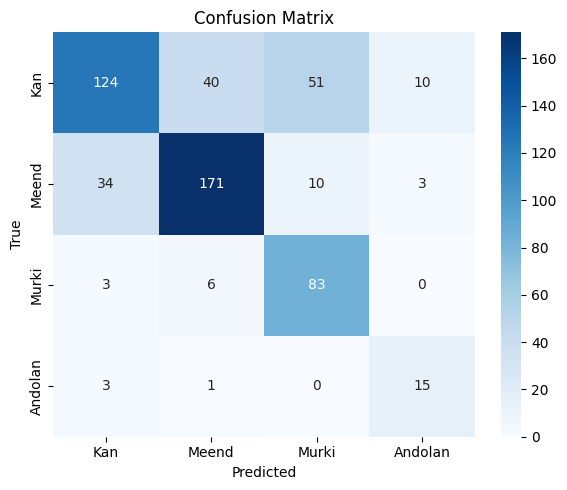

Precision: [0.75609756 0.78440367 0.57638889 0.53571429]
Recall:    [0.55111111 0.78440367 0.90217391 0.78947368]
F1:        [0.63753213 0.78440367 0.70338983 0.63829787]


In [14]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)

#### Without data augmentation 

##### loss:0.9083, trainacc = 0.643, testacc = 0.589
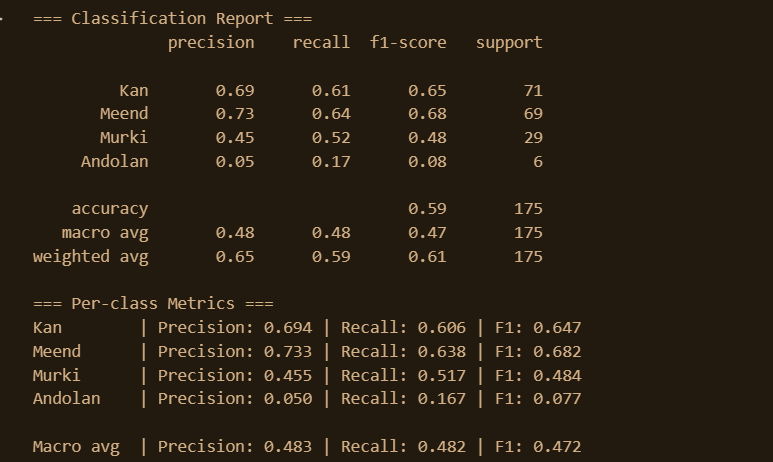

#### Cross validation for augmented data

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def cross_validate_tcn(X, y, label_map, n_splits=5, epochs=30, batch_size=16):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    fold_results = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X.reshape(len(X), -1), y)):
        print(f"\n{'='*50}")
        print(f"FOLD {fold+1}/{n_splits}")
        print(f"{'='*50}")
        
        # Split using indices directly on numpy arrays
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Use TensorDataset like your get_dataloaders
        train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
        test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_ds,  batch_size=batch_size)
        
        # Train
        model = train_tcn(train_loader, test_loader,
                          num_classes=len(label_map), epochs=epochs)
        
        # Evaluate
        print(f"\n--- Fold {fold+1} Evaluation ---")
        all_preds, all_labels, precision, recall, f1 = evaluate_model(
            model, test_loader, label_map
        )
        
        acc    = (all_preds == all_labels).mean()
        f1_mac = f1.mean()
        
        fold_results.append({
            "fold": fold + 1,
            "accuracy": acc,
            "macro_f1": f1_mac,
            "precision": precision,
            "recall": recall,
            "per_class_f1": f1,
            "all_preds": all_preds,
            "all_labels": all_labels
        })
    
    # Summary
    print(f"\n{'='*50}")
    print("CROSS VALIDATION SUMMARY")
    print(f"{'='*50}")
    
    accs = [r['accuracy'] for r in fold_results]
    f1s  = [r['macro_f1'] for r in fold_results]
    print(f"\nAccuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
    print(f"Macro F1: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    
    print("\nPer-class metrics across folds (mean ± std):")
    print(f"{'Class':10s} | {'Precision':>15s} | {'Recall':>15s} | {'F1':>15s}")
    print("-" * 65)
    for i, name in enumerate(target_names):
        prec_scores = [r['precision'][i]    for r in fold_results]
        rec_scores  = [r['recall'][i]       for r in fold_results]
        f1_scores   = [r['per_class_f1'][i] for r in fold_results]
        print(f"{name:10s} | "
              f"{np.mean(prec_scores):.3f} ± {np.std(prec_scores):.3f}  | "
              f"{np.mean(rec_scores):.3f} ± {np.std(rec_scores):.3f}  | "
              f"{np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
    
    # Combined confusion matrix
    all_preds_combined  = np.concatenate([r['all_preds']  for r in fold_results])
    all_labels_combined = np.concatenate([r['all_labels'] for r in fold_results])
    
    cm = confusion_matrix(all_labels_combined, all_preds_combined)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Combined Confusion Matrix (all folds)")
    plt.tight_layout()
    plt.show()
    
    return fold_results

X shape: (2770, 1, 117)
y shape: (2770,)
Skipped: 0
Label distribution: {'Kan': 1127, 'Meend': 1089, 'Murki': 459, 'Andolan': 95}

FOLD 1/5


Epoch 01 | Loss: 1.3303 | Train Acc: 0.463 | Test Acc: 0.581


Epoch 02 | Loss: 1.2171 | Train Acc: 0.579 | Test Acc: 0.610


Epoch 03 | Loss: 1.1643 | Train Acc: 0.578 | Test Acc: 0.625


Epoch 04 | Loss: 1.1102 | Train Acc: 0.613 | Test Acc: 0.644


...

Epoch 27 | Loss: 0.7055 | Train Acc: 0.699 | Test Acc: 0.706


Epoch 28 | Loss: 0.7108 | Train Acc: 0.694 | Test Acc: 0.742


Epoch 29 | Loss: 0.6760 | Train Acc: 0.697 | Test Acc: 0.693


Epoch 30 | Loss: 0.6843 | Train Acc: 0.710 | Test Acc: 0.709

--- Fold 1 Evaluation ---


=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.78      0.64      0.70       226
       Meend       0.72      0.78      0.75       218
       Murki       0.78      0.67      0.72        91
     Andolan       0.31      0.89      0.46        19

    accuracy                           0.71       554
   macro avg       0.65      0.75      0.66       554
weighted avg       0.74      0.71      0.72       554

=== Per-class Metrics ===
Kan        | Precision: 0.778 | Recall: 0.637 | F1: 0.701
Meend      | Precision: 0.725 | Recall: 0.784 | F1: 0.753
Murki      | Precision: 0.782 | Recall: 0.670 | F1: 0.722
Andolan    | Precision: 0.309 | Recall: 0.895 | F1: 0.459

Macro avg  | Precision: 0.649 | Recall: 0.747 | F1: 0.659


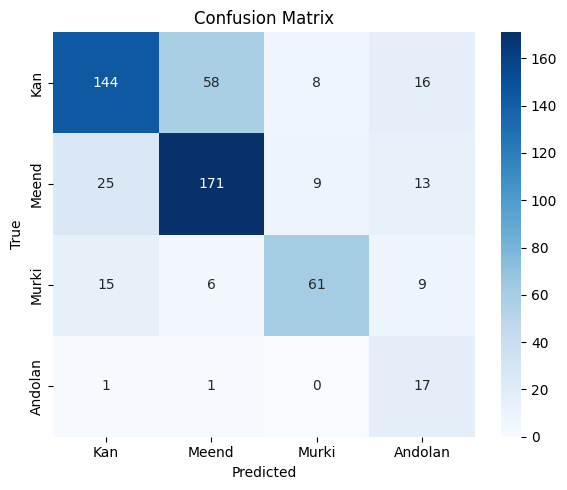


FOLD 2/5


Epoch 01 | Loss: 1.3005 | Train Acc: 0.476 | Test Acc: 0.592


Epoch 02 | Loss: 1.2204 | Train Acc: 0.550 | Test Acc: 0.612


Epoch 03 | Loss: 1.1683 | Train Acc: 0.557 | Test Acc: 0.570


Epoch 04 | Loss: 1.1274 | Train Acc: 0.559 | Test Acc: 0.558


...

Epoch 27 | Loss: 0.6857 | Train Acc: 0.701 | Test Acc: 0.742


Epoch 28 | Loss: 0.6872 | Train Acc: 0.699 | Test Acc: 0.691


Epoch 29 | Loss: 0.6612 | Train Acc: 0.710 | Test Acc: 0.686


Epoch 30 | Loss: 0.6519 | Train Acc: 0.718 | Test Acc: 0.695

--- Fold 2 Evaluation ---


=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.84      0.57      0.68       225
       Meend       0.82      0.73      0.77       218
       Murki       0.50      0.90      0.65        92
     Andolan       0.33      0.74      0.45        19

    accuracy                           0.69       554
   macro avg       0.62      0.74      0.64       554
weighted avg       0.76      0.69      0.70       554

=== Per-class Metrics ===
Kan        | Precision: 0.843 | Recall: 0.573 | F1: 0.683
Meend      | Precision: 0.824 | Recall: 0.729 | F1: 0.774
Murki      | Precision: 0.503 | Recall: 0.902 | F1: 0.646
Andolan    | Precision: 0.326 | Recall: 0.737 | F1: 0.452

Macro avg  | Precision: 0.624 | Recall: 0.735 | F1: 0.638


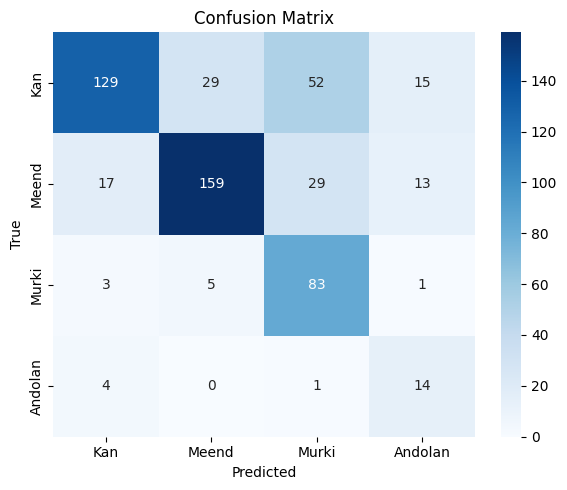


FOLD 3/5


Epoch 01 | Loss: 1.3108 | Train Acc: 0.512 | Test Acc: 0.439


Epoch 02 | Loss: 1.2358 | Train Acc: 0.532 | Test Acc: 0.578


Epoch 03 | Loss: 1.1783 | Train Acc: 0.566 | Test Acc: 0.612


Epoch 04 | Loss: 1.1397 | Train Acc: 0.566 | Test Acc: 0.643


...

Epoch 27 | Loss: 0.6677 | Train Acc: 0.709 | Test Acc: 0.673


Epoch 28 | Loss: 0.6758 | Train Acc: 0.722 | Test Acc: 0.648


Epoch 29 | Loss: 0.6631 | Train Acc: 0.724 | Test Acc: 0.677


Epoch 30 | Loss: 0.6485 | Train Acc: 0.728 | Test Acc: 0.637

--- Fold 3 Evaluation ---


=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.79      0.48      0.60       225
       Meend       0.76      0.71      0.73       218
       Murki       0.65      0.82      0.72        92
     Andolan       0.15      0.79      0.26        19

    accuracy                           0.64       554
   macro avg       0.59      0.70      0.58       554
weighted avg       0.73      0.64      0.66       554

=== Per-class Metrics ===
Kan        | Precision: 0.790 | Recall: 0.484 | F1: 0.601
Meend      | Precision: 0.759 | Recall: 0.706 | F1: 0.732
Murki      | Precision: 0.652 | Recall: 0.815 | F1: 0.725
Andolan    | Precision: 0.153 | Recall: 0.789 | F1: 0.256

Macro avg  | Precision: 0.588 | Recall: 0.699 | F1: 0.578


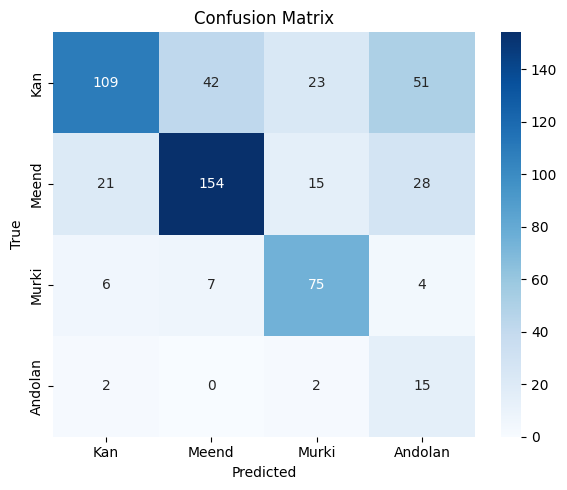


FOLD 4/5


Epoch 01 | Loss: 1.2877 | Train Acc: 0.529 | Test Acc: 0.489


Epoch 02 | Loss: 1.2042 | Train Acc: 0.558 | Test Acc: 0.554


Epoch 03 | Loss: 1.1489 | Train Acc: 0.578 | Test Acc: 0.606


Epoch 04 | Loss: 1.0920 | Train Acc: 0.603 | Test Acc: 0.599


...

Epoch 27 | Loss: 0.6908 | Train Acc: 0.699 | Test Acc: 0.643


Epoch 28 | Loss: 0.6674 | Train Acc: 0.709 | Test Acc: 0.664


Epoch 29 | Loss: 0.6681 | Train Acc: 0.706 | Test Acc: 0.691


Epoch 30 | Loss: 0.6660 | Train Acc: 0.707 | Test Acc: 0.646

--- Fold 4 Evaluation ---


=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.75      0.50      0.60       225
       Meend       0.74      0.74      0.74       218
       Murki       0.63      0.73      0.68        92
     Andolan       0.22      0.89      0.35        19

    accuracy                           0.65       554
   macro avg       0.58      0.72      0.59       554
weighted avg       0.71      0.65      0.66       554

=== Per-class Metrics ===
Kan        | Precision: 0.747 | Recall: 0.498 | F1: 0.597
Meend      | Precision: 0.736 | Recall: 0.743 | F1: 0.740
Murki      | Precision: 0.632 | Recall: 0.728 | F1: 0.677
Andolan    | Precision: 0.218 | Recall: 0.895 | F1: 0.351

Macro avg  | Precision: 0.583 | Recall: 0.716 | F1: 0.591


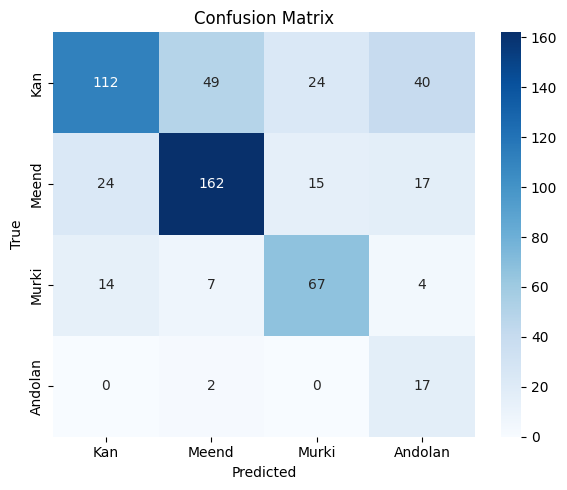


FOLD 5/5


Epoch 01 | Loss: 1.3053 | Train Acc: 0.508 | Test Acc: 0.588


Epoch 02 | Loss: 1.1959 | Train Acc: 0.557 | Test Acc: 0.579


Epoch 03 | Loss: 1.1465 | Train Acc: 0.583 | Test Acc: 0.644


Epoch 04 | Loss: 1.0922 | Train Acc: 0.600 | Test Acc: 0.632


...

Epoch 27 | Loss: 0.7190 | Train Acc: 0.702 | Test Acc: 0.724


Epoch 28 | Loss: 0.6904 | Train Acc: 0.700 | Test Acc: 0.668


Epoch 29 | Loss: 0.6996 | Train Acc: 0.695 | Test Acc: 0.681


Epoch 30 | Loss: 0.6488 | Train Acc: 0.710 | Test Acc: 0.736

--- Fold 5 Evaluation ---


=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.75      0.69      0.72       226
       Meend       0.75      0.77      0.76       217
       Murki       0.80      0.80      0.80        92
     Andolan       0.36      0.63      0.46        19

    accuracy                           0.74       554
   macro avg       0.67      0.72      0.69       554
weighted avg       0.75      0.74      0.74       554

=== Per-class Metrics ===
Kan        | Precision: 0.752 | Recall: 0.686 | F1: 0.718
Meend      | Precision: 0.749 | Recall: 0.770 | F1: 0.759
Murki      | Precision: 0.804 | Recall: 0.804 | F1: 0.804
Andolan    | Precision: 0.364 | Recall: 0.632 | F1: 0.462

Macro avg  | Precision: 0.667 | Recall: 0.723 | F1: 0.686


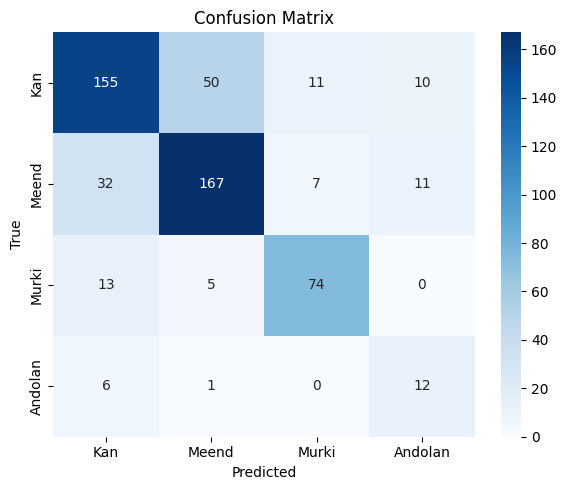


CROSS VALIDATION SUMMARY

Accuracy: 0.685 ± 0.038
Macro F1: 0.630 ± 0.040

Per-class metrics across folds (mean ± std):
Class      |       Precision |          Recall |              F1
-----------------------------------------------------------------
Kan        | 0.782 ± 0.034  | 0.576 ± 0.078  | 0.660 ± 0.051
Meend      | 0.758 ± 0.035  | 0.747 ± 0.028  | 0.751 ± 0.015
Murki      | 0.675 ± 0.110  | 0.784 ± 0.079  | 0.715 ± 0.054
Andolan    | 0.274 ± 0.077  | 0.789 ± 0.100  | 0.396 ± 0.081


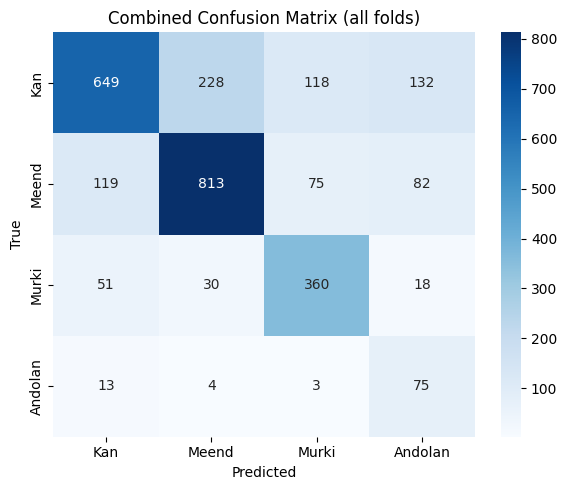

In [16]:
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=117)
fold_results = cross_validate_tcn(X, y, label_map, n_splits=5, epochs=30)

### Adaptive window

In [17]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
def prepare_tcn_input(segments, min_length=20):
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0
    
    # Filter too short
    segments = [s for s in segments if len(s['pitch_curve']) >= min_length]
    
    for seg in segments:
        curve = seg['pitch_curve'].copy()
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        else:
            skipped += 1
            continue
        
        X.append(torch.tensor(curve, dtype=torch.float32).unsqueeze(0))  # (1, length)
        y.append(label_map[label])
    
    y = torch.tensor(y, dtype=torch.int64)
    
    print(f"Total segments: {len(X)}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map  # X is now a list of variable length tensors

In [18]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """Pads sequences in each batch to the longest in that batch."""
    X_batch, y_batch = zip(*batch)
    lengths = torch.tensor([x.shape[-1] for x in X_batch])
    
    # Pad to longest sequence in this batch
    X_padded = pad_sequence(
        [x.squeeze(0) for x in X_batch], 
        batch_first=True
    ).unsqueeze(1)  # (batch, 1, max_len_in_batch)
    
    return X_padded, torch.tensor(y_batch), lengths

In [19]:
from torch.utils.data import Dataset

class OrnamentDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    # Split indices
    from sklearn.model_selection import train_test_split
    indices = list(range(len(X)))
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, 
        stratify=y.numpy(), random_state=42
    )
    
    X_train = [X[i] for i in train_idx]
    X_test  = [X[i] for i in test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]
    
    train_ds = OrnamentDataset(X_train, y_train)
    test_ds  = OrnamentDataset(X_test,  y_test)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, 
                              shuffle=True, collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, 
                              collate_fn=collate_fn)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

In [20]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection

class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # handles any length
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = self.adaptive_pool(out).squeeze(-1)  # (batch, channels)
        return self.classifier(out)

In [21]:
from sklearn.utils.class_weight import compute_class_weight

def train_tcn(train_loader, test_loader, num_classes=4, epochs=30):
    model = OrnamentTCN(input_size=1, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle class imbalance
    all_labels = train_loader.dataset.y.numpy()
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb, lengths in train_loader:  # unpack lengths too
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)
        # Evaluate
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for xb, yb, lengths in test_loader:
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
        
        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.3f} | "
              f"Test Acc: {test_correct/test_total:.3f}")
    
    return model

In [22]:
X, y, label_map = prepare_tcn_input(segments, min_length=20)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, epochs=30)

Total segments: 926
Skipped: 0
Label distribution: {'Kan': 378, 'Meend': 363, 'Murki': 153, 'Andolan': 32}
Train: 740 | Test: 186


Epoch 01 | Loss: 1.3557 | Train Acc: 0.493 | Test Acc: 0.344


Epoch 02 | Loss: 1.2958 | Train Acc: 0.503 | Test Acc: 0.565


Epoch 03 | Loss: 1.2529 | Train Acc: 0.589 | Test Acc: 0.559


Epoch 04 | Loss: 1.2445 | Train Acc: 0.581 | Test Acc: 0.548


...

Epoch 26 | Loss: 0.9154 | Train Acc: 0.677 | Test Acc: 0.634


Epoch 27 | Loss: 0.8868 | Train Acc: 0.684 | Test Acc: 0.651


Epoch 28 | Loss: 0.8959 | Train Acc: 0.692 | Test Acc: 0.618


Epoch 29 | Loss: 0.8709 | Train Acc: 0.685 | Test Acc: 0.634


Epoch 30 | Loss: 0.8739 | Train Acc: 0.669 | Test Acc: 0.532


=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.64      0.46      0.53        76
       Meend       0.73      0.59      0.65        73
       Murki       0.70      0.52      0.59        31
     Andolan       0.10      0.83      0.18         6

    accuracy                           0.53       186
   macro avg       0.54      0.60      0.49       186
weighted avg       0.67      0.53      0.58       186

=== Per-class Metrics ===
Kan        | Precision: 0.636 | Recall: 0.461 | F1: 0.534
Meend      | Precision: 0.729 | Recall: 0.589 | F1: 0.652
Murki      | Precision: 0.696 | Recall: 0.516 | F1: 0.593
Andolan    | Precision: 0.102 | Recall: 0.833 | F1: 0.182

Macro avg  | Precision: 0.541 | Recall: 0.600 | F1: 0.490


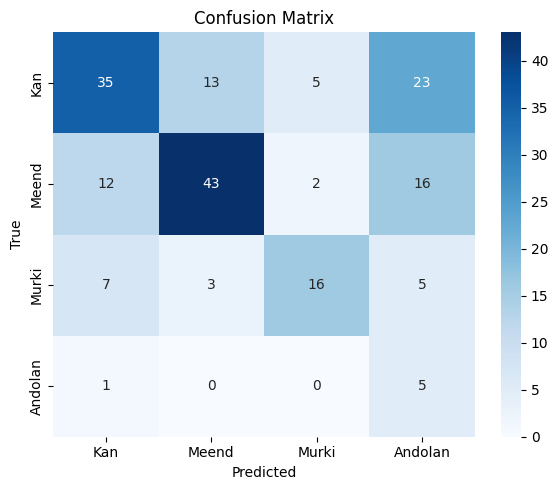

Precision: [0.63636364 0.72881356 0.69565217 0.10204082]
Recall:    [0.46052632 0.5890411  0.51612903 0.83333333]
F1:        [0.53435115 0.65151515 0.59259259 0.18181818]


In [23]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)